<a href="https://colab.research.google.com/github/Suguna-M/Suguna-M/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [15]:
print("First 5 rows of data:")
print(df.head())

print("\nInformation about data:")
print(df.info())

print("\nCount of missing values in each column:")
print(df.isnull().sum())


First 5 rows of data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

In [16]:
for column in df.columns:
    if df[column].dtype == 'float64' or df[column].dtype == 'int64':
        if df[column].isnull().sum() > 0:
            df[column].fillna(df[column].median(), inplace=True)

for column in df.columns:
    if df[column].dtype == 'object':
        if df[column].isnull().sum() > 0:
            df[column].fillna(df[column].mode()[0], inplace=True)

/tmp/ipython-input-16-443789241.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)
/tmp/ipython-input-16-443789241.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [17]:
df = pd.get_dummies(df)

from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


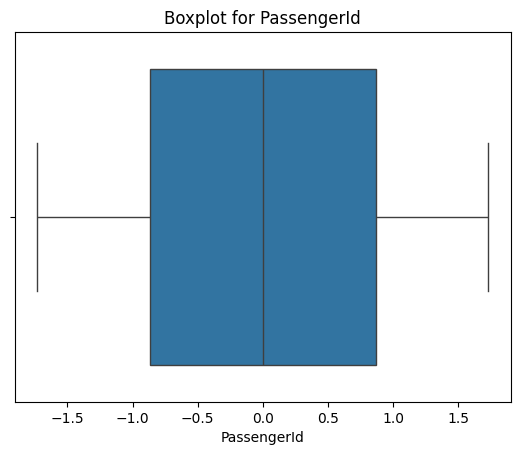

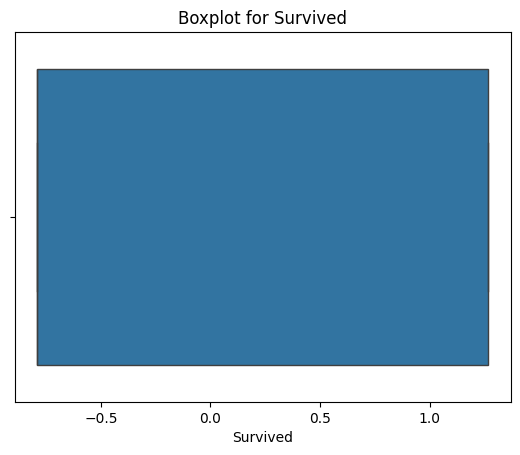

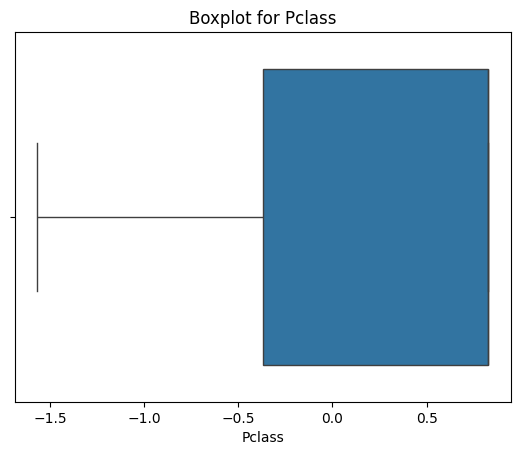

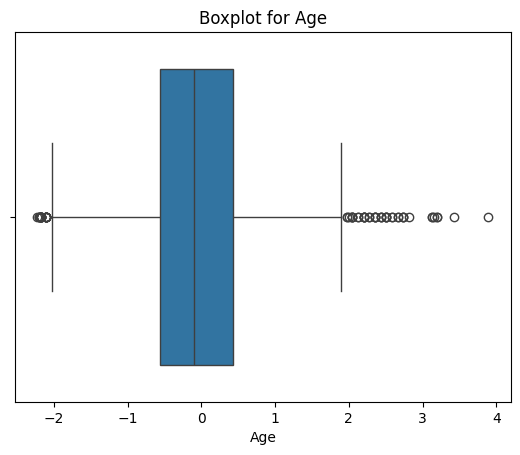

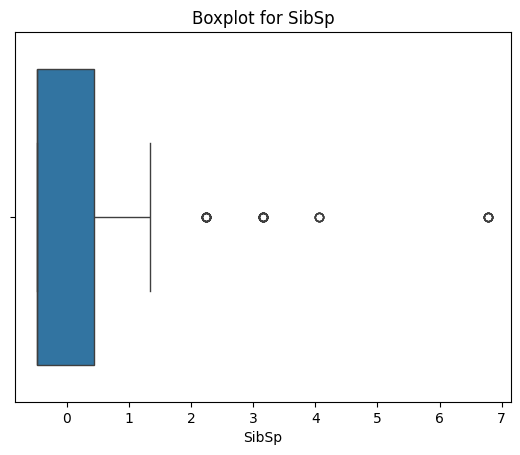

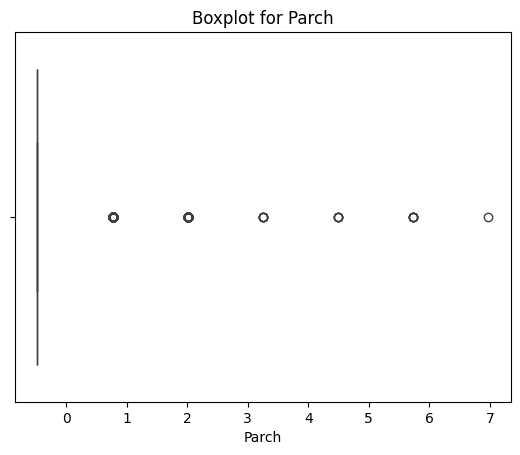

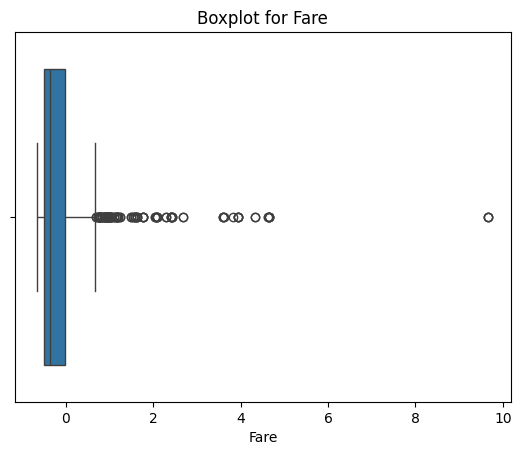

In [18]:
for column in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot for {column}')
    plt.show()


In [19]:
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower) & (df[column] <= upper)]

In [20]:
print("\nCleaned data (first 5 rows):")
print(df.head())


Cleaned data (first 5 rows):
   PassengerId  Survived    Pclass       Age     SibSp     Parch      Fare  \
0    -1.730108 -0.789272  0.827377 -0.565736  0.432793 -0.473674 -0.502445   
2    -1.722332  1.266990  0.827377 -0.258337 -0.474545 -0.473674 -0.488854   
3    -1.718444  1.266990 -1.566107  0.433312  0.432793 -0.473674  0.420730   
4    -1.714556 -0.789272  0.827377  0.433312 -0.474545 -0.473674 -0.486337   
5    -1.710669 -0.789272  0.827377 -0.104637 -0.474545 -0.473674 -0.478116   

   Name_Abbing, Mr. Anthony  Name_Abbott, Mr. Rossmore Edward  \
0                     False                             False   
2                     False                             False   
3                     False                             False   
4                     False                             False   
5                     False                             False   

   Name_Abbott, Mrs. Stanton (Rosa Hunt)  ...  Cabin_F G73  Cabin_F2  \
0                                  Fal